# EXP-006 — Hierarchical 2/4/6-mer Logistic Regression + GC201

**Статус:** подготовлен, но ни одна code cell не выполнена.

**Гипотеза.** При одинаковом локальном `2/4/6-mer` доля GC в
окне `[-100,+100]` содержит дополнительный переносимый сигнал
промоторного окружения.

**Меняем только feature set:** к EXP-005 добавляется один
стандартизованный числовой `GC201`. Target, split, локальные
k-mer, solver, class balancing и метрики остаются прежними.

Не используйте **Run All**. Выполняйте ячейки сверху вниз и
останавливайтесь на контрольных точках.


## Карта notebook

1. Проверить окружение, конфиг и неизменный contig split.
2. Посчитать на полном train точные `6-mer × GC201` статистики.
3. Посмотреть только train-распределение и enrichment GC.
4. Проверить число агрегированных строк и память.
5. Остановиться перед первым обучением.
6. Вручную выполнить train-contig CV и выбрать `C`.
7. Обучить один final candidate на полном train.
8. Только затем посчитать validation и сравнить candidate с
   EXP-005 и champion EXP-003.
9. Сохранить артефакты и обновить карточку отдельной последней
   ячейкой.


In [1]:
from pathlib import Path
import json
import platform
import sys
import time

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from IPython.display import Markdown, display

CURRENT_DIR = Path.cwd().resolve()
PROJECT_ROOT = next(
    candidate for candidate in (CURRENT_DIR, *CURRENT_DIR.parents)
    if (candidate / "README.md").is_file()
    and (candidate / "src/ml_project").is_dir()
)
SRC_DIR = PROJECT_ROOT / "src"
if str(SRC_DIR) not in sys.path:
    sys.path.insert(0, str(SRC_DIR))

from ml_project.epic_baseline import load_baseline_sequences
from ml_project.epic_data import ensure_prepared_split
from ml_project.epic_experiment import (
    ExperimentSpec,
    build_run_record,
    save_run_record,
)
from ml_project.epic_gc_logistic import (
    GCWindowLogisticConfig,
    aggregate_gc_binary_likelihood,
    cross_validate_gc_logistic,
    evaluate_gc_logistic,
    fit_gc_logistic,
    gc_count_diagnostics,
    gc_enrichment_table,
    kmer_counts_from_gc_counts,
    split_kmer_gc_counts,
)
from ml_project.epic_kmer import (
    KmerLookupConfig,
    evaluate_kmer_lookup,
    fit_kmer_lookup,
)
from ml_project.epic_kmer_logistic import (
    hierarchical_kmer_design,
    make_balanced_contig_folds,
    select_regularization,
    summarise_cv,
)

plt.rcParams.update({
    "figure.dpi": 120,
    "font.size": 10,
    "axes.spines.top": False,
    "axes.spines.right": False,
    "axes.titleweight": "bold",
})
pd.set_option("display.max_columns", 60)
pd.set_option("display.max_rows", 80)

display(pd.Series({
    "python": platform.python_version(),
    "executable": sys.executable,
    "project_root": str(PROJECT_ROOT),
    "notebook_state": "prepared / unexecuted",
}, name="value").to_frame())


,value
python,3.12.14
executable,C:\ML_Progs\Runtimes\Miniforge3\envs\epic-eda\...
project_root,D:\Projects\EPIC\EPIC
notebook_state,prepared / unexecuted


## 1. Зафиксированный конфиг

`GC201` — доля G/C среди валидных A/C/G/T в inclusive-окне
`[-100,+100]`. `N` и обрезанные края не считаются как AT.

В каждом CV-fold mean/std GC оцениваются только на fitting-contig.
Validation не участвует ни в scaling, ни в выборе `C`.


In [2]:
RUN_NAME = "run_001"
EXPERIMENT_ID = "EXP-006"
NOTEBOOK_PATH = PROJECT_ROOT / "notebooks/experiments/EXP-006_gc201_logistic.ipynb"
ARTIFACT_DIR = PROJECT_ROOT / "artifacts/experiments/EXP-006" / RUN_NAME
PLOT_DIR = ARTIFACT_DIR / "plots"

CONFIG = GCWindowLogisticConfig()
LOOKUP_CONFIG = KmerLookupConfig(
    ks=CONFIG.ks,
    smoothing="one_expected_positive",
)
SPEC = ExperimentSpec(
    experiment_id=EXPERIMENT_ID,
    title="Hierarchical 2/4/6-mer Logistic Regression + GC201",
    hypothesis=(
        "At fixed hierarchical 2/4/6-mer identity, GC fraction in "
        "the inclusive [-100,+100] window adds transferable promoter-context signal"
    ),
    changed_variable=(
        "EXP-005 hierarchical logistic features + one train-standardized GC201 scalar"
    ),
    success_criterion=(
        "Champion gate vs EXP-003: relative validation AP gain >= 1%, "
        "EPIC Spearman not lower, AP wins on at least 2/3 validation contigs"
    ),
    seed=CONFIG.seed,
)
assert not (ARTIFACT_DIR / "metadata.json").exists(), (
    f"Run already exists: {ARTIFACT_DIR}. Use another run name; do not overwrite."
)
display(pd.Series(CONFIG.to_dict(), name="value").to_frame())


,value
ks,"[2, 4, 6]"
window_start,-100
window_end,100
C_grid,"[0.0001, 0.0003, 0.001, 0.003, 0.01, 0.03, 0.1..."
penalty,l2
solver,lbfgs
max_iter,2000
tol,0.0
threads,2
seed,42


## 2. Неизменный split

Используется тот же `contig_holdout_v1`, что в EXP-001…005.
Все операции до validation-gate работают только с train-contig.


In [3]:
split = ensure_prepared_split(PROJECT_ROOT)
display(split.summary)
display(split.contig_assignment.sort_values(["split", "contig"]))
assert split.config.split_version == "contig_holdout_v1"
assert split.config.seed == CONFIG.seed
assert set(split.contig_assignment["split"]) == {"train", "validation", "test"}


,split,contigs,intervals_both_strands,whitelist_bp,position_strand_count,percent_of_all_positions,positive_positions,negative_positions,positive_percent
0,train,9,168998,114032080,228064160,59.316784,170443.0,227893717.0,0.074735
1,validation,3,60386,41903743,83807486,21.797334,56205.0,83751281.0,0.067064
2,test,3,54846,36306695,72613390,18.885882,NaN,NaN,NaN


,contig,split,source_split
12,NC_064037.1,test,test
13,NC_064044.1,test,test
14,NC_064046.1,test,test
1,NC_064035.1,train,train
2,NC_064036.1,train,train
3,NC_064038.1,train,train
4,NC_064039.1,train,train
5,NC_064040.1,train,train
8,NC_064043.1,train,train
9,NC_064045.1,train,train


In [4]:
sequences, fasta_alphabet = load_baseline_sequences(split)
display(pd.Series({
    "contigs_loaded": len(sequences),
    "total_fasta_bp": sum(map(len, sequences.values())),
    "alphabet": fasta_alphabet,
}, name="value").to_frame())


,value
contigs_loaded,47
total_fasta_bp,269418438
alphabet,"{'A': 54173800, 'C': 39020211, 'G': 38944862, ..."


## 3. Как считается GC201

Для каждого contig модуль один раз строит два prefix-array:
`cumsum(is_G_or_C)` и `cumsum(is_A_or_C_or_G_or_T)`.
Для координаты `p` используются границы
`[max(0,p-100), min(length,p+101))`; два вычитания дают
`gc_count` и `valid_count`.

Сохраняются целые sufficient statistics, а не округлённый float.
Полный likelihood агрегируется по
`contig × strand × 6-mer × gc_count × valid_count × target`.
Multiplicity каждой агрегированной строки передаётся модели через
`sample_weight`. Это точное представление без sampling.


In [5]:
started = time.monotonic()
train_gc_counts = split_kmer_gc_counts(
    split,
    sequences,
    "train",
    config=CONFIG,
)
train_count_seconds = time.monotonic() - started
train_gc_diagnostics = gc_count_diagnostics(train_gc_counts)
display(train_gc_diagnostics)
print(f"Full train counted in {train_count_seconds:.2f} s")


,split,aggregate_rows,positions,positives,unique_gc_fractions,zero_valid_positions,zero_valid_fraction,totals_memory_mib,positives_memory_mib
0,train,6070347,228064160,170443,7502,0,0.0,729.431013,24.382193


Full train counted in 32.47 s


In [6]:
expected_train = int(
    split.summary.loc[
        split.summary["split"] == "train", "position_strand_count"
    ].iloc[0]
)
expected_positive = int(
    split.summary.loc[
        split.summary["split"] == "train", "positive_positions"
    ].iloc[0]
)
assert int(train_gc_counts.totals["total_positions"].sum()) == expected_train
assert len(train_gc_counts.positives) == expected_positive
assert (
    train_gc_counts.totals["gc_count"]
    <= train_gc_counts.totals["valid_count"]
).all()
display(train_gc_counts.totals.head(10))
display(train_gc_counts.positives.head(10))


,contig,strand,kmer_6_code,gc_count,valid_count,total_positions
0,NC_064035.1,+,0,30,201,1
1,NC_064035.1,+,0,32,201,3
2,NC_064035.1,+,0,34,201,2
3,NC_064035.1,+,0,35,201,2
4,NC_064035.1,+,0,36,201,2
5,NC_064035.1,+,0,37,201,4
6,NC_064035.1,+,0,38,201,4
7,NC_064035.1,+,0,39,201,10
8,NC_064035.1,+,0,40,201,26
9,NC_064035.1,+,0,41,201,12


,template_index,contig,coordinate_0based,strand,count,kmer_6_code,gc_count,valid_count,gc_fraction
0,17031126,NC_064035.1,886447,+,2,44,70,201,0.348259
1,17032244,NC_064035.1,887565,+,1,1012,88,201,0.437811
2,17034634,NC_064035.1,890311,+,9,916,94,201,0.467662
3,17034774,NC_064035.1,890451,+,1,3456,77,201,0.383085
4,17036374,NC_064035.1,893355,+,1,423,72,201,0.358209
5,17036381,NC_064035.1,893362,+,2,538,72,201,0.358209
6,17051902,NC_064035.1,913273,+,1,3359,83,201,0.412935
7,17055629,NC_064035.1,917304,+,29,3476,82,201,0.407960
8,17055653,NC_064035.1,917328,+,1,320,81,201,0.402985
9,17055669,NC_064035.1,917344,+,1,4030,79,201,0.393035


## 4. Train-only диагностика GC

Fixed bins по 5 percentage points используются только для графика
и интерпретации. В модель поступает непрерывный GC201, bins не
являются признаками и не подбираются по validation.


,gc_bin,positions,positives,mean_gc,positive_rate,enrichment
0,"(-0.001, 0.05]",710,0,0.000989,0.000000,0.000000
1,"(0.05, 0.1]",762,0,0.084803,0.000000,0.000000
2,"(0.1, 0.15]",7440,0,0.135296,0.000000,0.000000
3,"(0.15, 0.2]",95866,2,0.185106,0.000021,0.027915
4,"(0.2, 0.25]",1326908,38,0.236282,0.000029,0.038320
5,"(0.25, 0.3]",12164212,1057,0.283155,0.000087,0.116270
6,"(0.3, 0.35]",40997654,9041,0.329095,0.000221,0.295077
7,"(0.35, 0.4]",62769492,35534,0.376080,0.000566,0.757484
8,"(0.4, 0.45]",56255440,62203,0.424081,0.001106,1.479533
9,"(0.45, 0.5]",34044686,45084,0.472233,0.001324,1.771948


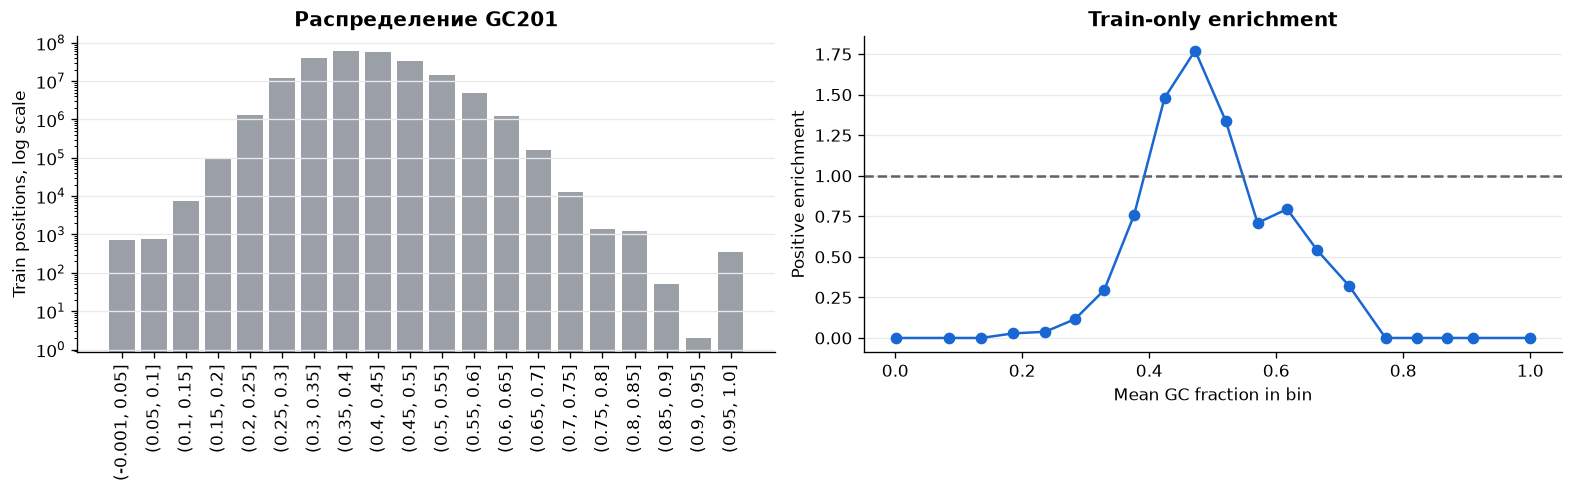

In [7]:
train_gc_enrichment = gc_enrichment_table(train_gc_counts, bin_width=0.05)
display(train_gc_enrichment)

fig_train_gc, axes = plt.subplots(1, 2, figsize=(13, 4), constrained_layout=True)
axes[0].bar(
    train_gc_enrichment["gc_bin"],
    train_gc_enrichment["positions"],
    color="#9AA0A6",
)
axes[0].set_yscale("log")
axes[0].set_ylabel("Train positions, log scale")
axes[0].set_title("Распределение GC201")
axes[1].plot(
    train_gc_enrichment["mean_gc"],
    train_gc_enrichment["enrichment"],
    marker="o",
    color="#1967D2",
)
axes[1].axhline(1.0, color="#5F6368", linestyle="--")
axes[1].set_xlabel("Mean GC fraction in bin")
axes[1].set_ylabel("Positive enrichment")
axes[1].set_title("Train-only enrichment")
for ax in axes:
    ax.grid(axis="y", color="#E8EAED")
axes[0].tick_params(axis="x", rotation=90)
plt.show()


## 5. Model-ready представление и память

6-mer однозначно задаёт suffix 4-mer и 2-mer. Candidate имеет
`4 371` one-hot столбец EXP-005 и один numeric `gc201_z`, всего
`4 372` признака. Для каждой позиции активны три one-hot и одно
числовое значение.


In [8]:
train_kmer_counts = kmer_counts_from_gc_counts(
    train_gc_counts,
    ks=CONFIG.ks,
)
design = hierarchical_kmer_design(CONFIG)
train_aggregate_preview = aggregate_gc_binary_likelihood(
    train_gc_counts,
    design,
    balance_classes=CONFIG.balance_classes,
)
aggregate_report = pd.Series({
    "hierarchical_one_hot_columns": design.matrix.shape[1],
    "candidate_columns": train_aggregate_preview.matrix.shape[1],
    "aggregate_binary_rows": len(train_aggregate_preview.rows),
    "represented_positions": int(
        train_aggregate_preview.rows["population_count"].sum()
    ),
    "gc_train_mean": train_aggregate_preview.gc_mean,
    "gc_train_std": train_aggregate_preview.gc_std,
    "matrix_memory_mib": (
        train_aggregate_preview.matrix.data.nbytes
        + train_aggregate_preview.matrix.indices.nbytes
        + train_aggregate_preview.matrix.indptr.nbytes
    ) / 2**20,
}, name="value").to_frame()
display(aggregate_report)
assert train_aggregate_preview.matrix.shape[1] == 4372
assert int(train_aggregate_preview.rows["population_count"].sum()) == expected_train


,value
hierarchical_one_hot_columns,4.371000e+03
candidate_columns,4.372000e+03
aggregate_binary_rows,5.341590e+05
represented_positions,2.280642e+08
gc_train_mean,4.025935e-01
gc_train_std,7.007069e-02
matrix_memory_mib,2.648952e+01


In [9]:
fold_assignment = make_balanced_contig_folds(
    train_kmer_counts,
    k=CONFIG.max_k,
    n_splits=CONFIG.cv_folds,
)
display(fold_assignment)
assert not fold_assignment["contig"].duplicated().any()
assert set(fold_assignment["fold"]) == set(range(CONFIG.cv_folds))


,contig,positions,positives,fold,prevalence
0,NC_064035.1,33456756,30987,0,0.000926
1,NC_064043.1,24039838,19558,0,0.000814
2,NC_064048.1,17926958,10888,0,0.000607
3,NC_064036.1,31610378,26323,1,0.000833
4,NC_064038.1,25217952,14793,1,0.000587
5,NC_064045.1,20367114,15184,1,0.000746
6,NC_064039.1,27686596,21975,2,0.000794
7,NC_064040.1,26051020,19067,2,0.000732
8,NC_064047.1,21707548,11668,2,0.000538


In [10]:
display(pd.DataFrame({
    "C": CONFIG.C_grid,
    "regularization_strength_1_over_C": [1 / value for value in CONFIG.C_grid],
    "max_iter": CONFIG.max_iter,
    "tol": CONFIG.tol,
}))
print(f"Planned fits: {len(CONFIG.C_grid)} C × {CONFIG.cv_folds} folds")


,C,regularization_strength_1_over_C,max_iter,tol
0,0.0001,10000.000000,2000,1.000000e-08
1,0.0003,3333.333333,2000,1.000000e-08
2,0.0010,1000.000000,2000,1.000000e-08
3,0.0030,333.333333,2000,1.000000e-08
4,0.0100,100.000000,2000,1.000000e-08
5,0.0300,33.333333,2000,1.000000e-08
6,0.1000,10.000000,2000,1.000000e-08
7,0.3000,3.333333,2000,1.000000e-08
8,1.0000,1.000000,2000,1.000000e-08
9,3.0000,0.333333,2000,1.000000e-08


Planned fits: 13 C × 3 folds


# STOP 1 — дальше начинается обучение

До этой точки выполнены только чтение данных, подсчёт GC/k-mer,
агрегация, train-only EDA и folds. Ни одна модель не обучена.

Перед следующей ячейкой проверьте:

- population и positives совпали с manifest;
- `candidate_columns = 4372`;
- число агрегированных строк и память приемлемы;
- validation ещё не считался;
- grid содержит 39 запланированных fits.


In [11]:
started = time.monotonic()
cv_results = cross_validate_gc_logistic(
    train_gc_counts,
    fold_assignment,
    config=CONFIG,
)
cv_seconds = time.monotonic() - started
print(f"Train-only CV finished in {cv_seconds:.2f} s")
display(cv_results.head())


Train-only CV finished in 1013.61 s


,C,fold,validation_contigs,segment,variant,average_precision,epic_spearman,population_log_loss,balanced_log_loss,positions,positives,prevalence,unique_score_levels,iterations,converged,fit_seconds,aggregate_rows,gc_mean,gc_std,gc_coefficient,warnings
0,0.0001,0,"NC_064035.1,NC_064043.1,NC_064048.1","NC_064035.1,NC_064043.1,NC_064048.1",hierarchical_2_4_6mer_lr_plus_gc201,0.002072,0.081236,0.605398,0.605093,75423552,61433,0.000815,395871,242,True,4.594,494092,0.403159,0.070754,0.530390,
1,0.0001,1,"NC_064036.1,NC_064038.1,NC_064045.1","NC_064036.1,NC_064038.1,NC_064045.1",hierarchical_2_4_6mer_lr_plus_gc201,0.001709,0.093797,0.616640,0.611683,77195444,56300,0.000729,399489,247,True,4.718,494517,0.401997,0.069557,0.548979,
2,0.0001,2,"NC_064039.1,NC_064040.1,NC_064047.1","NC_064039.1,NC_064040.1,NC_064047.1",hierarchical_2_4_6mer_lr_plus_gc201,0.001665,0.085305,0.611257,0.608372,75445164,52710,0.000699,397969,247,True,4.796,498235,0.402617,0.069885,0.553185,
3,0.0003,0,"NC_064035.1,NC_064043.1,NC_064048.1","NC_064035.1,NC_064043.1,NC_064048.1",hierarchical_2_4_6mer_lr_plus_gc201,0.002081,0.082775,0.603498,0.605141,75423552,61433,0.000815,395871,378,True,7.265,494092,0.403159,0.070754,0.528027,
4,0.0003,1,"NC_064036.1,NC_064038.1,NC_064045.1","NC_064036.1,NC_064038.1,NC_064045.1",hierarchical_2_4_6mer_lr_plus_gc201,0.001719,0.095225,0.614632,0.611793,77195444,56300,0.000729,399489,385,True,7.407,494517,0.401997,0.069557,0.546828,


In [12]:
cv_summary = summarise_cv(cv_results)
nonconverged = cv_summary.loc[
    ~cv_summary["all_folds_converged"].astype(bool)
]
display(cv_summary.style.format({
    "mean_average_precision": "{:.9f}",
    "std_average_precision": "{:.9f}",
    "mean_epic_spearman": "{:.6f}",
    "std_epic_spearman": "{:.6f}",
    "mean_balanced_log_loss": "{:.6f}",
    "total_fit_seconds": "{:.2f}",
}))
if len(nonconverged):
    display(Markdown(
        "**Несошедшиеся C автоматически исключаются из выбора:** "
        + ", ".join(map(str, nonconverged["C"]))
    ))
assert cv_summary["all_folds_converged"].any(), "Ни один C не сошёлся"


,C,mean_average_precision,std_average_precision,mean_epic_spearman,std_epic_spearman,mean_balanced_log_loss,all_folds_converged,max_iterations,total_fit_seconds
0,0.000100,0.001815657,0.000223457,0.086780,0.006409,0.608383,True,247,14.11
1,0.000300,0.001824806,0.000223302,0.088277,0.006350,0.608440,True,395,22.36
2,0.001000,0.001823263,0.000222043,0.088899,0.006381,0.609506,True,617,34.91
3,0.003000,0.001820296,0.000221309,0.089025,0.006406,0.610374,True,894,48.84
4,0.010000,0.001818615,0.000220981,0.089052,0.006418,0.610877,True,1301,66.05
5,0.030000,0.001818048,0.000220889,0.089059,0.006422,0.611076,True,1756,84.08
6,0.100000,0.001817834,0.000220856,0.089060,0.006423,0.611176,True,1589,86.58
7,0.300000,0.001817772,0.000220842,0.089060,0.006424,0.611228,False,2000,92.62
8,1.000000,0.001817750,0.000220837,0.089060,0.006424,0.611271,False,2000,91.22
9,3.000000,0.001817742,0.000220835,0.089061,0.006424,0.611303,False,2000,92.09


**Несошедшиеся C автоматически исключаются из выбора:** 0.3, 1.0, 3.0, 10.0, 30.0, 100.0

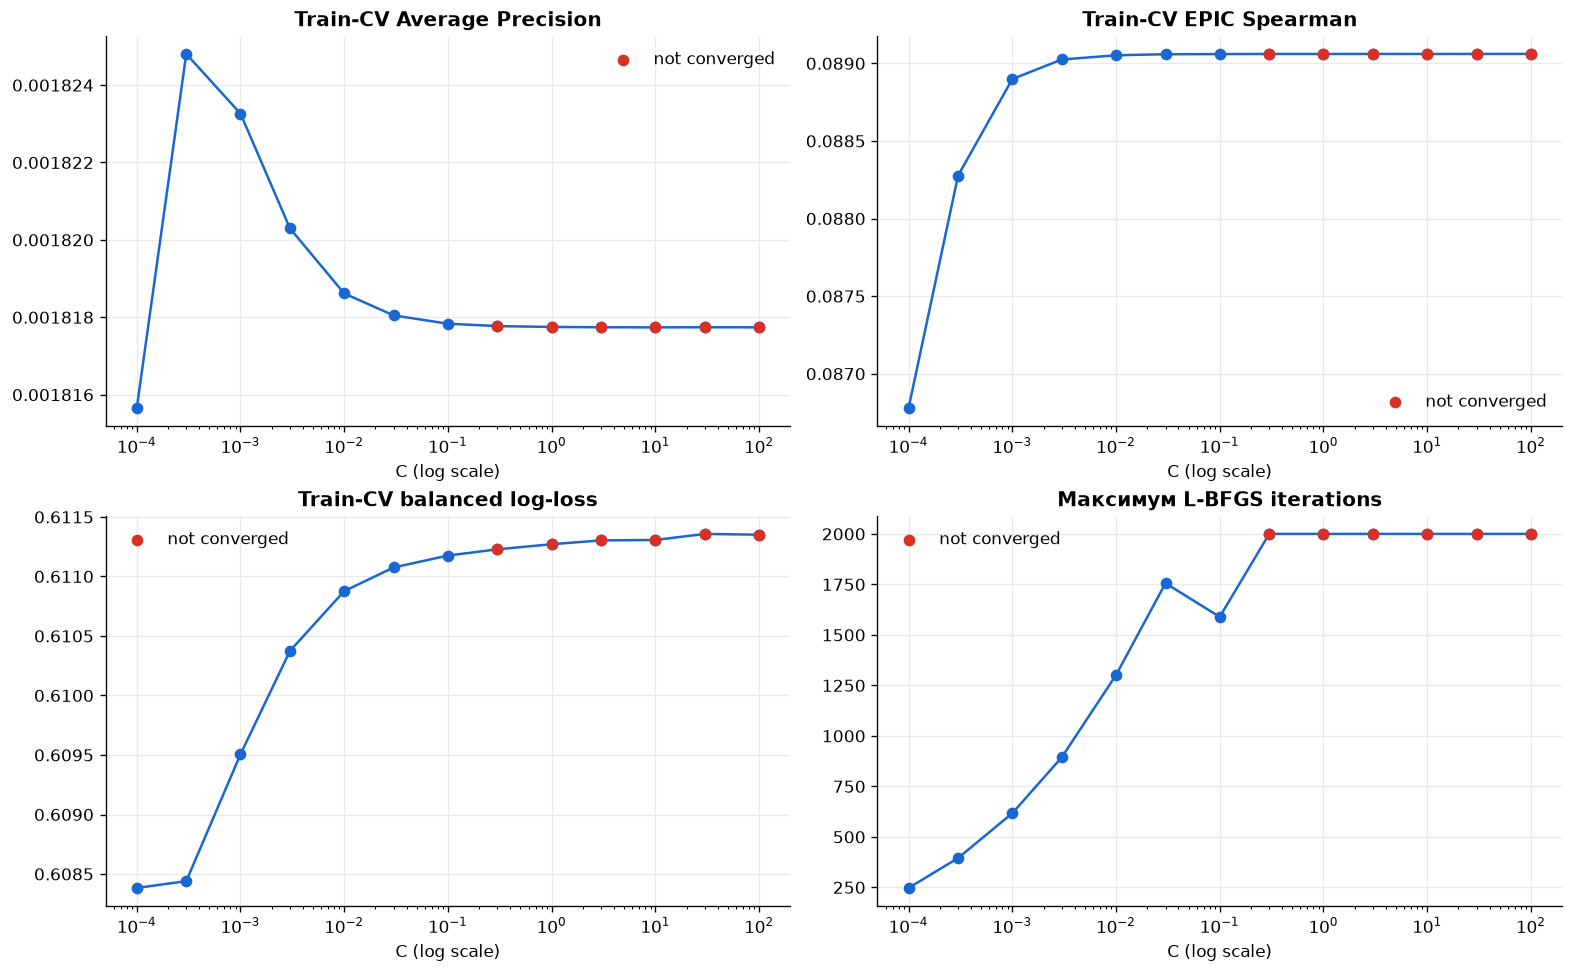

In [13]:
fig_cv, axes = plt.subplots(2, 2, figsize=(13, 8), constrained_layout=True)
panels = [
    ("mean_average_precision", "Train-CV Average Precision", axes[0, 0]),
    ("mean_epic_spearman", "Train-CV EPIC Spearman", axes[0, 1]),
    ("mean_balanced_log_loss", "Train-CV balanced log-loss", axes[1, 0]),
    ("max_iterations", "Максимум L-BFGS iterations", axes[1, 1]),
]
for column, title, ax in panels:
    ax.plot(cv_summary["C"], cv_summary[column], marker="o", color="#1967D2")
    failed = ~cv_summary["all_folds_converged"].astype(bool)
    ax.scatter(
        cv_summary.loc[failed, "C"],
        cv_summary.loc[failed, column],
        color="#D93025",
        label="not converged",
        zorder=3,
    )
    ax.set_xscale("log")
    ax.set_xlabel("C (log scale)")
    ax.set_title(title)
    ax.grid(color="#E8EAED")
    if failed.any():
        ax.legend(frameon=False)
plt.show()


In [14]:
selected = select_regularization(
    cv_summary,
    relative_ap_tolerance=CONFIG.near_best_relative_ap,
)
SELECTED_C = float(selected["C"])
display(selected.to_frame("selected_value"))
print(f"Frozen C before validation: {SELECTED_C:g}")


,selected_value
C,0.0003
mean_average_precision,0.001825
std_average_precision,0.000223
mean_epic_spearman,0.088277
std_epic_spearman,0.00635
mean_balanced_log_loss,0.60844
all_folds_converged,True
max_iterations,395
total_fit_seconds,22.36


Frozen C before validation: 0.0003


# STOP 2 — C должен быть зафиксирован

Проверьте CV-графики, convergence и строку выбранного `C`.
Следующая ячейка обучит ровно одну candidate-модель на полном train.
Validation всё ещё закрыт.


In [15]:
started = time.monotonic()
final_fit = fit_gc_logistic(
    train_gc_counts,
    C=SELECTED_C,
    config=CONFIG,
    design=design,
)
full_fit_seconds = time.monotonic() - started
display(final_fit.fit_report)
assert bool(final_fit.fit_report.iloc[0]["converged"]), (
    "Final candidate did not converge; do not open validation."
)
print(f"Full-train candidate fit in {full_fit_seconds:.2f} s")


,C,solver,penalty,tol,iterations,max_iter,converged,fit_seconds,aggregate_rows,features,represented_positions,represented_positives,gc_mean,gc_std,gc_coefficient,intercept,warnings
0,0.0003,lbfgs,l2,1.000000e-08,449,2000,True,9.437,534159,4372,228064160,170443,0.402593,0.070071,0.540805,-0.397266,


Full-train candidate fit in 10.16 s


In [16]:
gc_coefficient_row = final_fit.coefficient_table.loc[
    final_fit.coefficient_table["feature_name"] == "gc201_z"
].iloc[0]
gc_beta = float(gc_coefficient_row["coefficient"])
gc_std = float(final_fit.fit_report.iloc[0]["gc_std"])
gc_effect_summary = pd.Series({
    "gc_coefficient_per_1_sd": gc_beta,
    "odds_multiplier_per_1_sd": np.exp(gc_beta),
    "odds_multiplier_per_10_percentage_points": np.exp(gc_beta * 0.10 / gc_std),
    "gc_train_mean": final_fit.fit_report.iloc[0]["gc_mean"],
    "gc_train_std": gc_std,
}, name="value").to_frame()
display(gc_effect_summary)
display(
    final_fit.coefficient_table.nlargest(20, "absolute_coefficient")[
        ["feature_name", "feature_group", "coefficient", "absolute_coefficient"]
    ]
)


,value
gc_coefficient_per_1_sd,0.540805
odds_multiplier_per_1_sd,1.717389
odds_multiplier_per_10_percentage_points,2.163657
gc_train_mean,0.402593
gc_train_std,0.070071


,feature_name,feature_group,coefficient,absolute_coefficient
3004,k6=GGGGGG,6-mer,-1.358603,1.358603
4,k2=CA,2-mer,1.222366,1.222366
1893,k6=CGCCAT,6-mer,1.134100,1.134100
3008,k6=GGGGTG,6-mer,-1.037416,1.037416
2996,k6=GGGGAG,6-mer,-1.019724,1.019724
12,k2=TA,2-mer,0.944236,0.944236
102,k4=CCCC,4-mer,-0.905953,0.905953
3405,k6=TAATGT,6-mer,-0.836561,0.836561
2885,k6=GGATAT,6-mer,0.793046,0.793046
3855,k6=TCTTTC,6-mer,0.791417,0.791417


# STOP 3 — только теперь открывается validation

До этой точки зафиксированы feature formula, folds, C, scaler
protocol и final fit. Следующая ячейка впервые считает GC201 на
трёх validation-contig. После просмотра метрик параметры менять
нельзя; новое изменение потребует нового experiment ID.


In [17]:
started = time.monotonic()
validation_gc_counts = split_kmer_gc_counts(
    split,
    sequences,
    "validation",
    config=CONFIG,
)
validation_count_seconds = time.monotonic() - started
validation_gc_diagnostics = gc_count_diagnostics(validation_gc_counts)
validation_kmer_counts = kmer_counts_from_gc_counts(
    validation_gc_counts,
    ks=CONFIG.ks,
)
display(validation_gc_diagnostics)
print(f"Full validation counted in {validation_count_seconds:.2f} s")


,split,aggregate_rows,positions,positives,unique_gc_fractions,zero_valid_positions,zero_valid_fraction,totals_memory_mib,positives_memory_mib
0,validation,2054867,83807486,56205,4950,0,0.0,246.919035,8.040316


Full validation counted in 11.81 s


In [18]:
candidate_evaluation = evaluate_gc_logistic(
    validation_gc_counts,
    final_fit,
    variant="EXP-006 hierarchical LR + GC201",
)
candidate_row = candidate_evaluation.metric_summary.iloc[0]
display(candidate_evaluation.metric_summary)
display(candidate_evaluation.per_contig_metrics)


,segment,variant,average_precision,epic_spearman,population_log_loss,balanced_log_loss,positions,positives,prevalence,unique_score_levels
0,overall,EXP-006 hierarchical LR + GC201,0.001574,0.101205,0.616899,0.610786,83807486,56205,0.000671,402720


,contig,segment,variant,average_precision,epic_spearman,population_log_loss,balanced_log_loss,positions,positives,prevalence,unique_score_levels
0,NC_064034.1,NC_064034.1,EXP-006 hierarchical LR + GC201,0.001687,0.114905,0.614386,0.606653,33949114,23529,0.000693,367548
1,NC_064041.1,NC_064041.1,EXP-006 hierarchical LR + GC201,0.001340,0.123050,0.611806,0.612817,24146754,13984,0.000579,359679
2,NC_064042.1,NC_064042.1,EXP-006 hierarchical LR + GC201,0.001640,0.115082,0.625001,0.615033,25711618,18692,0.000727,366463


In [19]:
lookup_fit = fit_kmer_lookup(train_kmer_counts, LOOKUP_CONFIG)
lookup_evaluation = evaluate_kmer_lookup(validation_kmer_counts, lookup_fit)
exp003_row = lookup_evaluation.metric_summary.loc[
    lookup_evaluation.metric_summary["k"] == 6
].iloc[0]
assert np.isclose(exp003_row["average_precision"], 0.0016005373755008387)
assert np.isclose(exp003_row["epic_spearman"], 0.09718557212273755)
display(exp003_row.to_frame("EXP-003"))


,EXP-003
segment,overall
segment_value,overall
k,6
variant,6mer_lookup
average_precision,0.001601
epic_spearman,0.097186
positions,83807486
positives,56205
prevalence,0.000671
unique_score_levels,4097


In [20]:
EXP005_DIR = PROJECT_ROOT / "artifacts/experiments/EXP-005/run_001"
exp005_metadata = json.loads(
    (EXP005_DIR / "metadata.json").read_text(encoding="utf-8")
)
exp005_per_contig = pd.read_csv(EXP005_DIR / "per_contig_metrics.csv")
exp005_pr = pd.read_csv(EXP005_DIR / "precision_recall.csv")
exp005_ap = float(exp005_metadata["metrics"]["candidate_average_precision"])
exp005_spearman = float(exp005_metadata["metrics"]["candidate_epic_spearman"])
display(pd.Series({
    "EXP-005 AP": exp005_ap,
    "EXP-005 Spearman": exp005_spearman,
    "EXP-005 decision": exp005_metadata["run"]["decision"],
}, name="value").to_frame())


,value
EXP-005 AP,0.001606
EXP-005 Spearman,0.097569
EXP-005 decision,reject


In [21]:
metric_summary = pd.DataFrame([
    {
        "variant": "EXP-003 6-mer lookup",
        "average_precision": float(exp003_row["average_precision"]),
        "epic_spearman": float(exp003_row["epic_spearman"]),
    },
    {
        "variant": "EXP-005 hierarchical LR",
        "average_precision": exp005_ap,
        "epic_spearman": exp005_spearman,
    },
    {
        "variant": "EXP-006 LR + GC201",
        "average_precision": float(candidate_row["average_precision"]),
        "epic_spearman": float(candidate_row["epic_spearman"]),
    },
])
display(metric_summary)

exp003_contigs = lookup_evaluation.per_contig_metrics.loc[
    lookup_evaluation.per_contig_metrics["k"] == 6,
    ["segment_value", "average_precision", "epic_spearman"],
].rename(columns={
    "segment_value": "contig",
    "average_precision": "exp003_average_precision",
    "epic_spearman": "exp003_epic_spearman",
})
exp005_contigs = exp005_per_contig.rename(columns={
    "candidate_average_precision": "exp005_average_precision",
    "candidate_epic_spearman": "exp005_epic_spearman",
})[["contig", "exp005_average_precision", "exp005_epic_spearman"]]
candidate_contigs = candidate_evaluation.per_contig_metrics.rename(columns={
    "average_precision": "candidate_average_precision",
    "epic_spearman": "candidate_epic_spearman",
})[["contig", "candidate_average_precision", "candidate_epic_spearman"]]
per_contig_metrics = (
    exp003_contigs
    .merge(exp005_contigs, on="contig", validate="one_to_one")
    .merge(candidate_contigs, on="contig", validate="one_to_one")
)
display(per_contig_metrics)


,variant,average_precision,epic_spearman
0,EXP-003 6-mer lookup,0.001601,0.097186
1,EXP-005 hierarchical LR,0.001606,0.097569
2,EXP-006 LR + GC201,0.001574,0.101205


,contig,exp003_average_precision,exp003_epic_spearman,exp005_average_precision,exp005_epic_spearman,candidate_average_precision,candidate_epic_spearman
0,NC_064034.1,0.001717,0.109397,0.001725,0.109559,0.001687,0.114905
1,NC_064041.1,0.001381,0.120721,0.001386,0.121407,0.001340,0.123050
2,NC_064042.1,0.001655,0.115426,0.001658,0.116599,0.001640,0.115082


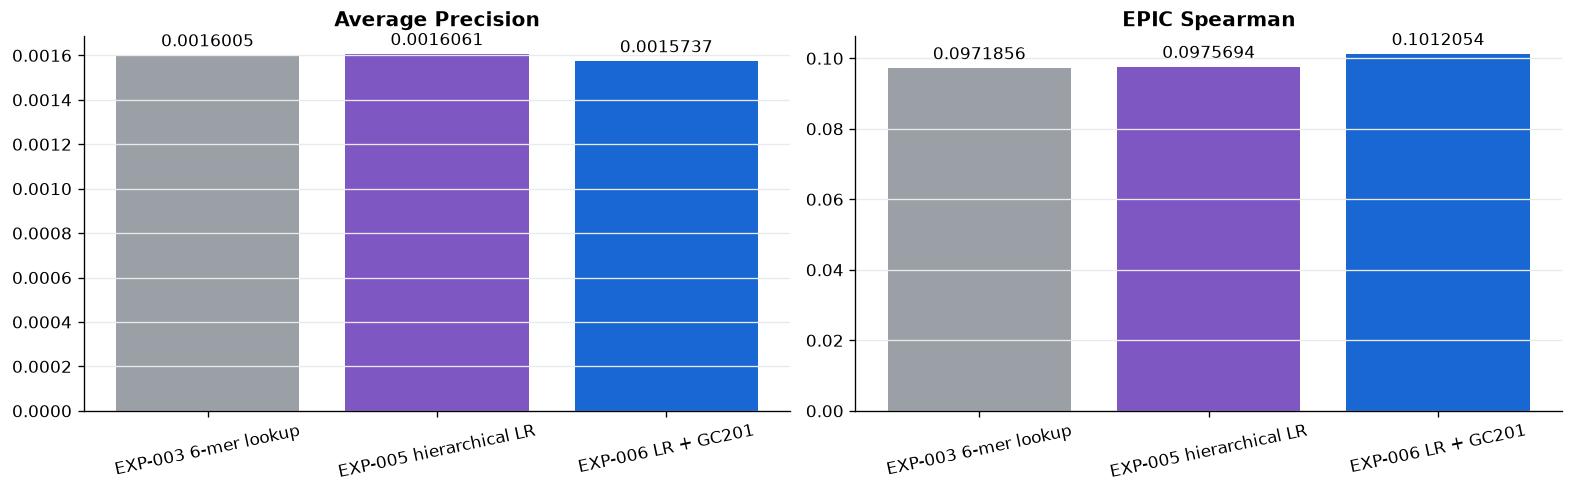

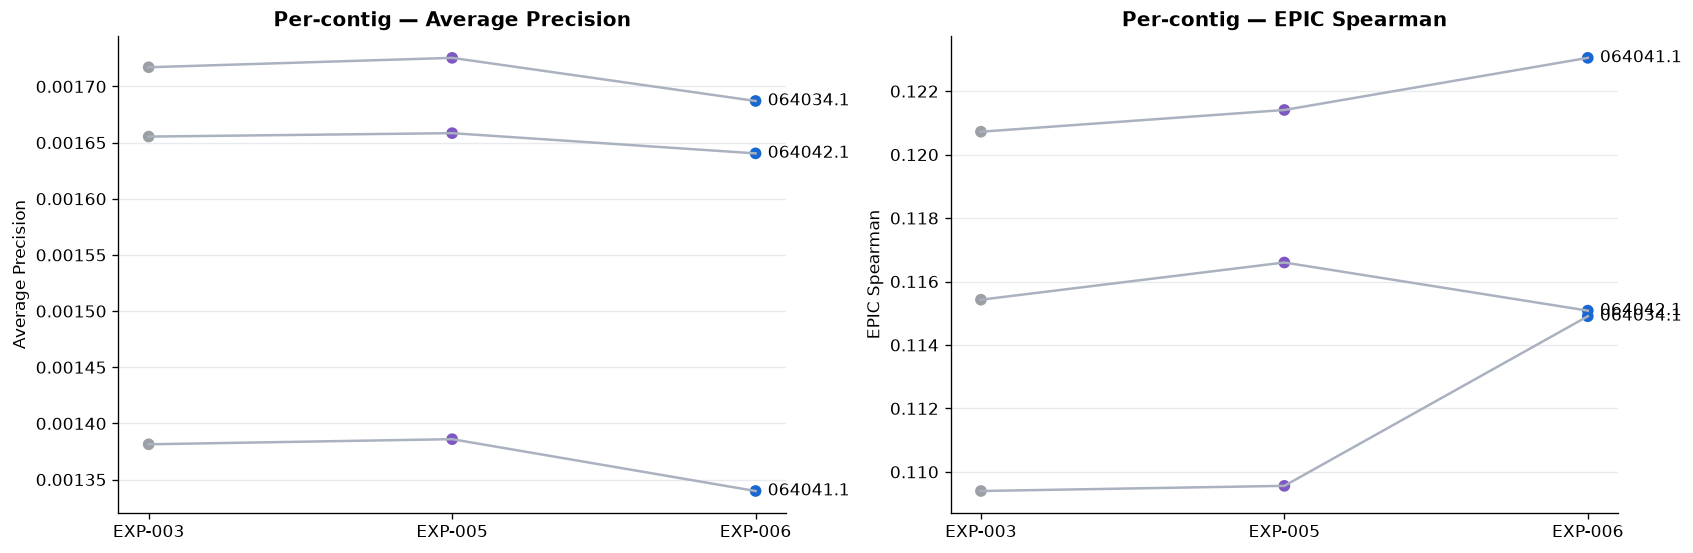

In [22]:
colors = ["#9AA0A6", "#7E57C2", "#1967D2"]
fig_metrics, axes = plt.subplots(1, 2, figsize=(13, 4), constrained_layout=True)
for ax, metric, title in [
    (axes[0], "average_precision", "Average Precision"),
    (axes[1], "epic_spearman", "EPIC Spearman"),
]:
    bars = ax.bar(metric_summary["variant"], metric_summary[metric], color=colors)
    ax.bar_label(bars, fmt="%.7f", padding=3)
    ax.set_title(title)
    ax.tick_params(axis="x", rotation=12)
    ax.grid(axis="y", color="#E8EAED")
plt.show()

fig_contigs, axes = plt.subplots(1, 2, figsize=(14, 4.5), constrained_layout=True)
for ax, metric, label in [
    (axes[0], "average_precision", "Average Precision"),
    (axes[1], "epic_spearman", "EPIC Spearman"),
]:
    columns = [f"exp003_{metric}", f"exp005_{metric}", f"candidate_{metric}"]
    for _, row in per_contig_metrics.iterrows():
        values = [row[column] for column in columns]
        ax.plot([0, 1, 2], values, color="#AAB2C0")
        ax.scatter([0, 1, 2], values, color=colors)
        ax.text(2.04, values[-1], row["contig"].replace("NC_", ""), va="center")
    ax.set_xticks([0, 1, 2], ["EXP-003", "EXP-005", "EXP-006"])
    ax.set_ylabel(label)
    ax.set_title(f"Per-contig — {label}")
    ax.grid(axis="y", color="#E8EAED")
plt.show()


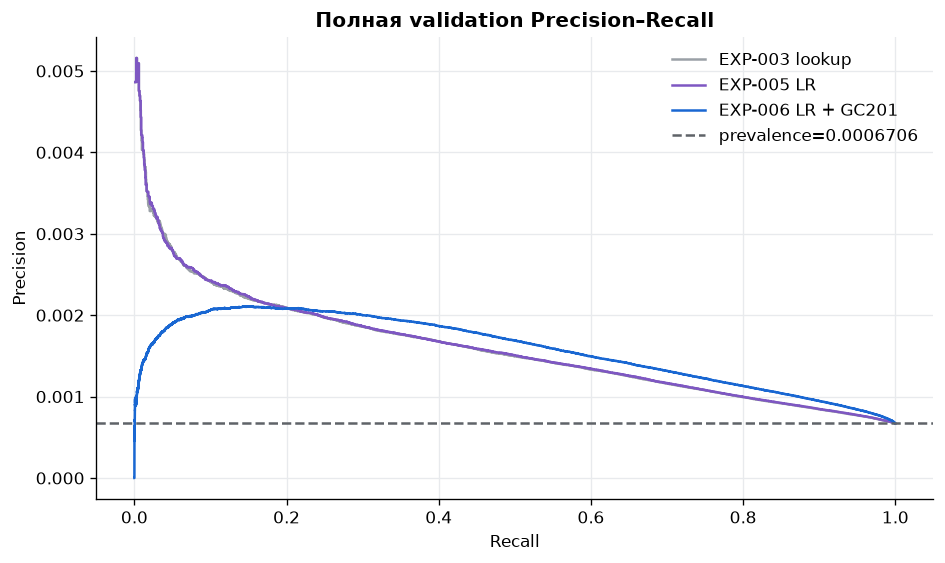

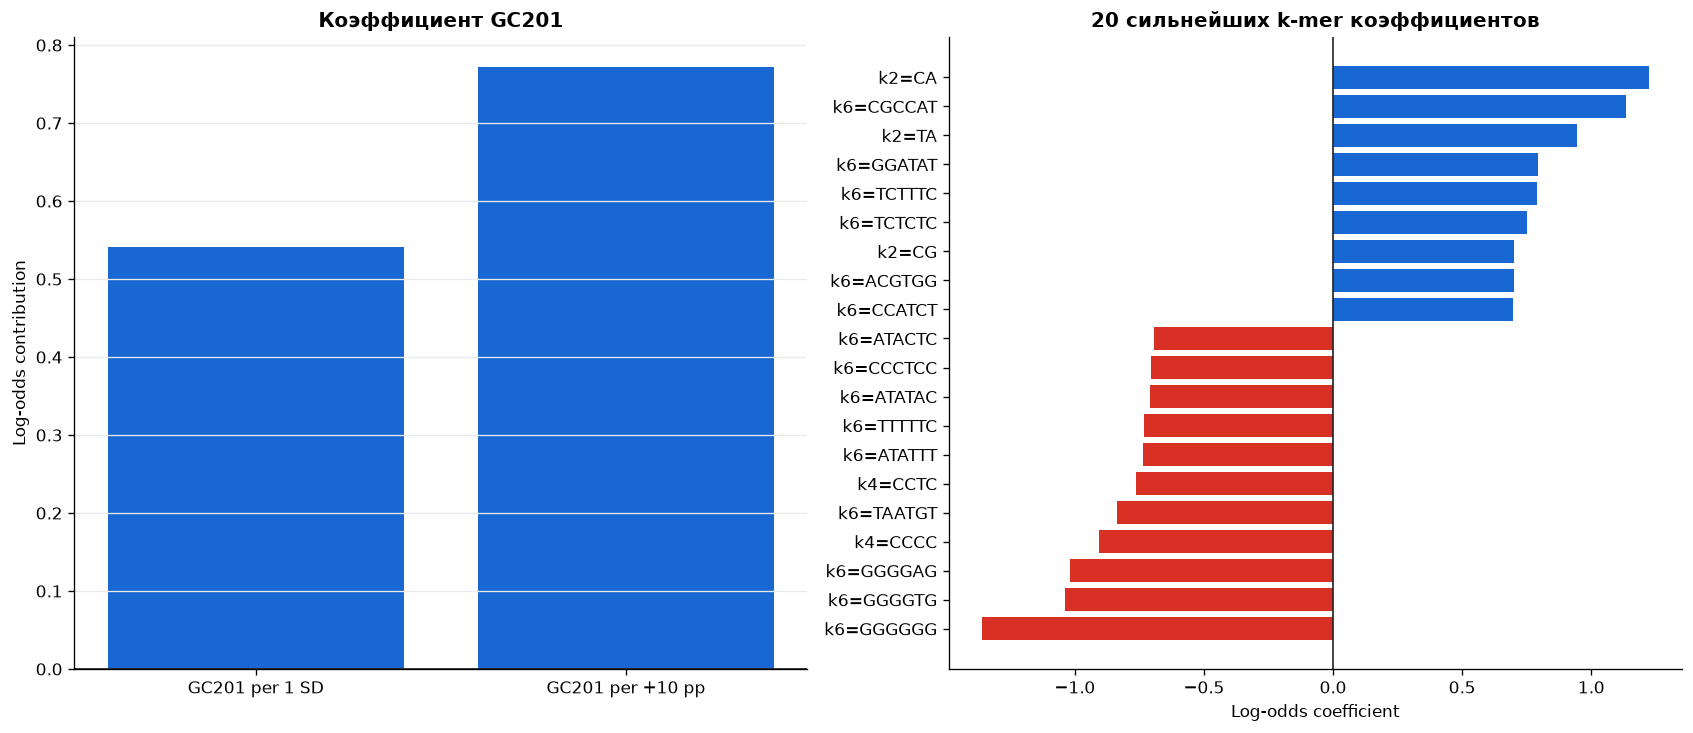

In [23]:
reference_pr = lookup_evaluation.precision_recall.loc[
    lookup_evaluation.precision_recall["k"] == 6
]
candidate_pr = candidate_evaluation.precision_recall
fig_pr, ax = plt.subplots(figsize=(9, 5))
ax.step(reference_pr["recall"], reference_pr["precision"], where="post",
        color="#9AA0A6", label="EXP-003 lookup")
ax.step(exp005_pr["recall"], exp005_pr["precision"], where="post",
        color="#7E57C2", label="EXP-005 LR")
ax.step(candidate_pr["recall"], candidate_pr["precision"], where="post",
        color="#1967D2", label="EXP-006 LR + GC201")
ax.axhline(candidate_row["prevalence"], color="#5F6368", linestyle="--",
           label=f"prevalence={candidate_row['prevalence']:.7f}")
ax.set_xlabel("Recall")
ax.set_ylabel("Precision")
ax.set_title("Полная validation Precision–Recall")
ax.legend(frameon=False)
ax.grid(color="#E8EAED")
plt.show()

strongest = (
    final_fit.coefficient_table.loc[
        final_fit.coefficient_table["feature_name"] != "gc201_z"
    ]
    .nlargest(20, "absolute_coefficient")
    .sort_values("coefficient")
)
fig_coefficients, axes = plt.subplots(1, 2, figsize=(14, 6), constrained_layout=True)
axes[0].bar(
    ["GC201 per 1 SD", "GC201 per +10 pp"],
    [gc_beta, gc_beta * 0.10 / gc_std],
    color="#1967D2",
)
axes[0].axhline(0, color="#202124", linewidth=1)
axes[0].set_ylabel("Log-odds contribution")
axes[0].set_title("Коэффициент GC201")
axes[0].grid(axis="y", color="#E8EAED")
axes[1].barh(
    strongest["feature_name"],
    strongest["coefficient"],
    color=np.where(strongest["coefficient"] >= 0, "#1967D2", "#D93025"),
)
axes[1].axvline(0, color="#202124", linewidth=1)
axes[1].set_xlabel("Log-odds coefficient")
axes[1].set_title("20 сильнейших k-mer коэффициентов")
plt.show()


## 10. Механическое решение

Feature ablation проверяется против EXP-005, а принятие нового
champion — против EXP-003. Критерии не меняются после просмотра
validation.


In [24]:
candidate_ap = float(candidate_row["average_precision"])
candidate_spearman = float(candidate_row["epic_spearman"])
exp003_ap = float(exp003_row["average_precision"])
exp003_spearman = float(exp003_row["epic_spearman"])

feature_ap_wins = int((
    per_contig_metrics["candidate_average_precision"]
    > per_contig_metrics["exp005_average_precision"]
).sum())
champion_ap_wins = int((
    per_contig_metrics["candidate_average_precision"]
    > per_contig_metrics["exp003_average_precision"]
).sum())
feature_checks = pd.Series({
    "AP > EXP-005": candidate_ap > exp005_ap,
    "Spearman >= EXP-005": candidate_spearman >= exp005_spearman,
    "AP wins vs EXP-005 on at least 2/3 contigs": feature_ap_wins >= 2,
}, name="passed")
champion_checks = pd.Series({
    "relative AP gain vs EXP-003 >= 1%": candidate_ap / exp003_ap - 1 >= 0.01,
    "Spearman >= EXP-003": candidate_spearman >= exp003_spearman,
    "AP wins vs EXP-003 on at least 2/3 contigs": champion_ap_wins >= 2,
}, name="passed")
display(Markdown("### Feature ablation vs EXP-005"))
display(feature_checks.to_frame())
display(Markdown("### Champion gate vs EXP-003"))
display(champion_checks.to_frame())

if bool(champion_checks.all()):
    DECISION = "adopt"
elif bool(feature_checks.all()):
    DECISION = "iterate"
else:
    DECISION = "reject"
INTERPRETATION = (
    f"GC201 changed AP vs EXP-005 from {exp005_ap:.9f} to {candidate_ap:.9f} "
    f"({candidate_ap / exp005_ap - 1:+.2%}) and Spearman from "
    f"{exp005_spearman:.6f} to {candidate_spearman:.6f}; "
    f"vs EXP-003 AP change is {candidate_ap / exp003_ap - 1:+.2%}. "
    f"Decision: {DECISION}."
)
display(Markdown(f"**Decision: `{DECISION}`.** {INTERPRETATION}"))


### Feature ablation vs EXP-005

,passed
AP > EXP-005,False
Spearman >= EXP-005,True
AP wins vs EXP-005 on at least 2/3 contigs,False


### Champion gate vs EXP-003

,passed
relative AP gain vs EXP-003 >= 1%,False
Spearman >= EXP-003,True
AP wins vs EXP-003 on at least 2/3 contigs,False


**Decision: `reject`.** GC201 changed AP vs EXP-005 from 0.001606098 to 0.001573742 (-2.01%) and Spearman from 0.097569 to 0.101205; vs EXP-003 AP change is -1.67%. Decision: reject.

## 11. Сохранение — выполнять последней

Ячейка создаёт `artifacts/experiments/EXP-006/run_001` и не
перезаписывает существующий run. Она сохраняет метрики, CV,
коэффициенты, GC-диагностику и все графики.


In [25]:
PLOT_DIR.mkdir(parents=True, exist_ok=True)
plot_objects = {
    "01_train_gc_enrichment.png": fig_train_gc,
    "02_train_cv_diagnostics.png": fig_cv,
    "03_validation_metrics.png": fig_metrics,
    "04_per_contig_metrics.png": fig_contigs,
    "05_precision_recall.png": fig_pr,
    "06_coefficients_gc.png": fig_coefficients,
}
for filename, figure in plot_objects.items():
    figure.savefig(
        PLOT_DIR / filename,
        dpi=170,
        bbox_inches="tight",
        facecolor="white",
    )

criteria_table = pd.concat(
    [
        feature_checks.rename("passed").to_frame().assign(comparison="EXP-005"),
        champion_checks.rename("passed").to_frame().assign(comparison="EXP-003"),
    ]
).rename_axis("criterion").reset_index()
precision_recall = pd.concat(
    [
        reference_pr.assign(variant="EXP-003 6-mer lookup"),
        exp005_pr.assign(variant="EXP-005 hierarchical LR"),
        candidate_pr.assign(variant="EXP-006 LR + GC201"),
    ],
    ignore_index=True,
)
tables = {
    "train_gc_diagnostics.csv": train_gc_diagnostics,
    "validation_gc_diagnostics.csv": validation_gc_diagnostics,
    "train_gc_enrichment.csv": train_gc_enrichment,
    "cv_fold_assignment.csv": fold_assignment,
    "cv_results.csv": cv_results,
    "cv_summary.csv": cv_summary,
    "metric_summary.csv": metric_summary,
    "per_contig_metrics.csv": per_contig_metrics,
    "criteria.csv": criteria_table,
    "fit_report.csv": final_fit.fit_report,
    "coefficient_table.csv": final_fit.coefficient_table,
    "precision_recall.csv": precision_recall,
}
for filename, table in tables.items():
    table.to_csv(ARTIFACT_DIR / filename, index=False)
candidate_evaluation.positive_predictions.to_csv(
    ARTIFACT_DIR / "positive_predictions.csv.gz",
    index=False,
    compression="gzip",
)

METRICS = {
    "reference_average_precision": exp003_ap,
    "candidate_average_precision": candidate_ap,
    "delta_average_precision": candidate_ap - exp003_ap,
    "reference_epic_spearman": exp003_spearman,
    "candidate_epic_spearman": candidate_spearman,
    "delta_epic_spearman": candidate_spearman - exp003_spearman,
    "ablation_reference_average_precision": exp005_ap,
    "ablation_delta_average_precision": candidate_ap - exp005_ap,
    "ablation_reference_epic_spearman": exp005_spearman,
    "ablation_delta_epic_spearman": candidate_spearman - exp005_spearman,
}
PARAMETERS = CONFIG.to_dict() | {
    "selected_C": SELECTED_C,
    "reference_experiment": "EXP-003/run_001",
    "ablation_reference": "EXP-005/run_001",
    "validation_population": "all whitelist positions",
    "validation_used_for_C_selection": False,
    "score": "raw float64 logistic decision_function",
}
record = build_run_record(
    SPEC,
    split,
    run_name=RUN_NAME,
    notebook_path=NOTEBOOK_PATH,
    parameters=PARAMETERS,
    metrics=METRICS,
    interpretation=INTERPRETATION,
    decision=DECISION,
)
output = save_run_record(PROJECT_ROOT, record)
(output / "config.json").write_text(
    json.dumps(PARAMETERS, ensure_ascii=False, indent=2) + "\n",
    encoding="utf-8",
)
print("Saved run:", output)


Saved run: D:\Projects\EPIC\EPIC\artifacts\experiments\EXP-006\run_001


## 12. Обновить карточку эксперимента

Финальная ячейка читает только сохранённые CSV/JSON и графики,
записывает отчёт в `experiments/EXP-006.md` и не переобучает модель.
Ручной анализ за границами auto-block сохраняется.


In [26]:
from ml_project.epic_gc_report import sync_exp006_report

experiment_note = sync_exp006_report(PROJECT_ROOT, run_name=RUN_NAME)
print("Updated experiment note:", experiment_note)


Updated experiment note: D:\Projects\EPIC\EPIC\experiments\EXP-006.md
